In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from astroquery.mast import Observations
from astropy.io import fits
from scipy.signal import medfilt
from astropy.stats import sigma_clip
from astropy.timeseries import BoxLeastSquares
from scipy.ndimage import uniform_filter1d

os.makedirs("figures", exist_ok=True)

INFO: Found cached file tess2026033082000-s0100-0000000021113347-0302-s_lc.fits with expected size 1935360. [astroquery.query]


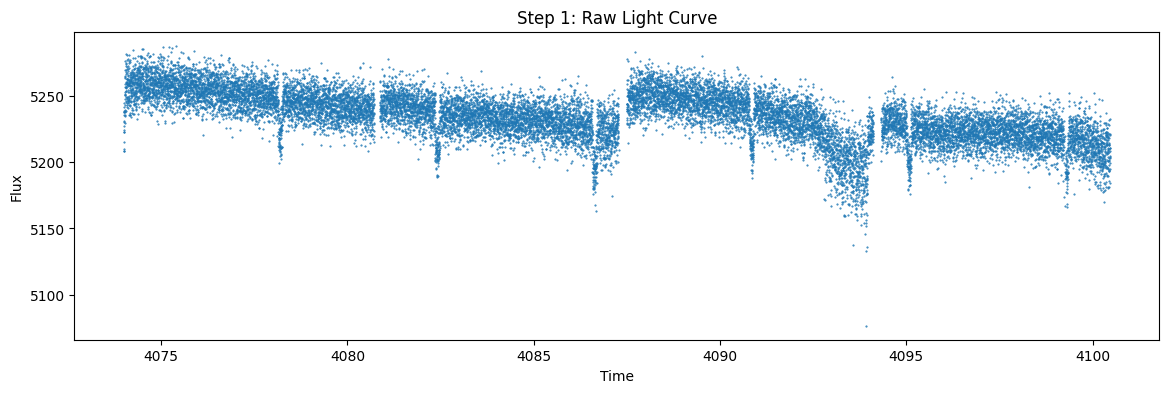

In [2]:
# =========================================================
# Step 1: Raw Light Curve
# =========================================================

uri = "mast:TESS/product/tess2026033082000-s0100-0000000021113347-0302-s_lc.fits"

result = Observations.download_file(
    uri,
    base_url='https://mast.stsci.edu/api/v0.1/Download/file'
)

filename = uri.rsplit('/', 1)[-1]
local_path = os.path.join(os.path.abspath('.'), filename)

hdul = fits.open(local_path)
data = hdul[1].data

time = data['TIME'].astype(np.float64)
flux = data['SAP_FLUX'].astype(np.float64)

mask = np.isfinite(time) & np.isfinite(flux)
time = time[mask]
flux = flux[mask]

plt.figure(figsize=(14,4))
plt.plot(time, flux, '.', markersize=1)
plt.title("Step 1: Raw Light Curve")
plt.xlabel("Time")
plt.ylabel("Flux")

plt.savefig("figures/step1_raw.png", dpi=300, bbox_inches='tight')
plt.show()

hdul.close()

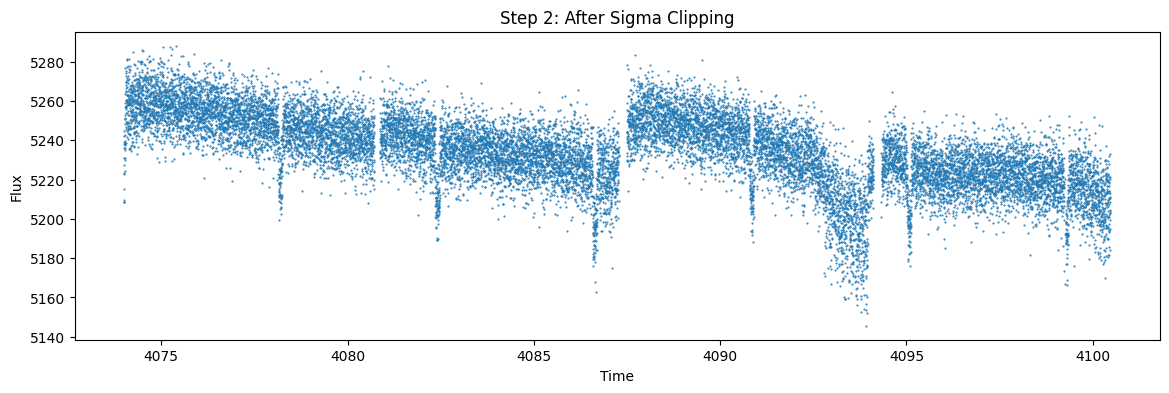

In [3]:
# =========================================================
# Step 2: Sigma Clipping 
# =========================================================

flux_clip = sigma_clip(flux, sigma=5, maxiters=3)
mask = ~flux_clip.mask

time = time[mask]
flux = flux[mask]

plt.figure(figsize=(14,4))
plt.plot(time, flux, '.', markersize=1)
plt.title("Step 2: After Sigma Clipping")
plt.xlabel("Time")
plt.ylabel("Flux")


plt.savefig("figures/step2_clip.png", dpi=300, bbox_inches='tight')
plt.show()


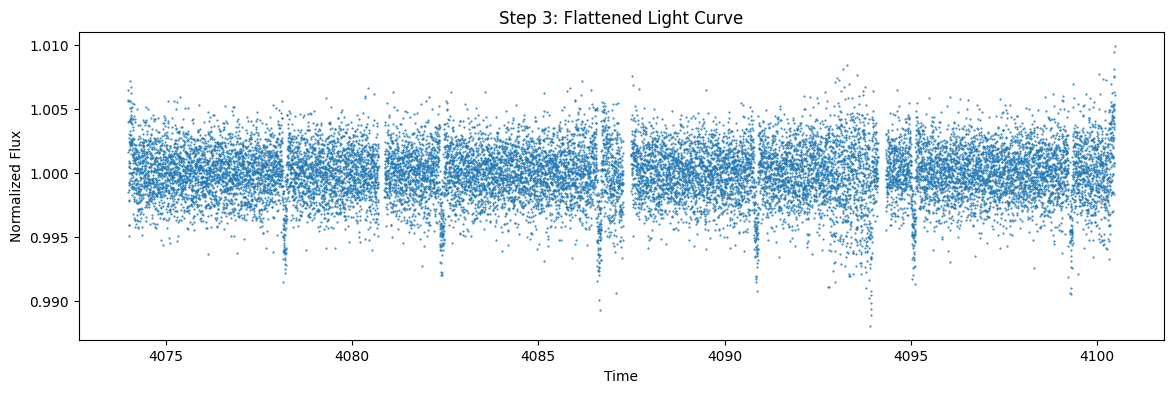

In [4]:
# =========================================================
# Step 3: Detrending
# =========================================================

trend = medfilt(flux, kernel_size=301)
flux_flat = flux / trend

plt.figure(figsize=(14,4))
plt.plot(time, flux_flat, '.', markersize=1)
plt.title("Step 3: Flattened Light Curve")
plt.xlabel("Time")
plt.ylabel("Normalized Flux")


plt.savefig("figures/step3_flat.png", dpi=300, bbox_inches='tight')
plt.show()


4.220944188837768 4078.1825679865474 0.105


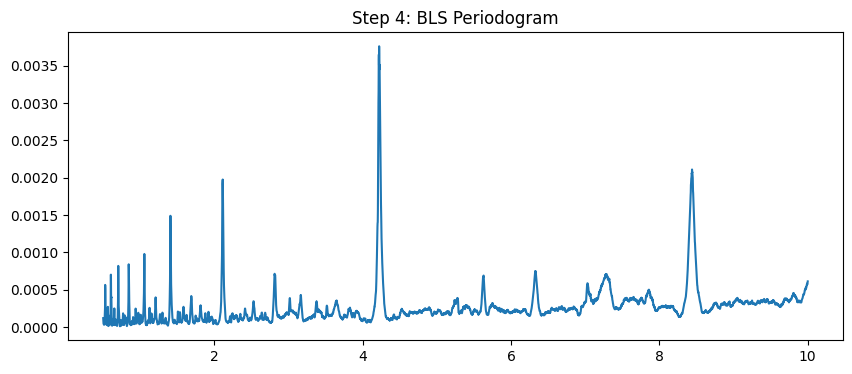

In [5]:
# =========================================================
# Step 4: BLS Period Search
# =========================================================

bls = BoxLeastSquares(time, flux_flat)

periods = np.linspace(0.5, 10, 5000)
durations = np.linspace(0.05, 0.3, 10)

result = bls.power(periods, durations)

best_idx = np.argmax(result.power)

P = result.period[best_idx]
t0 = result.transit_time[best_idx]
Tdur = result.duration[best_idx]

plt.figure(figsize=(10,4))
plt.plot(result.period, result.power)
plt.title("Step 4: BLS Periodogram")


print(P, t0, Tdur)

plt.savefig("figures/step4_bls.png", dpi=300, bbox_inches='tight')
plt.show()


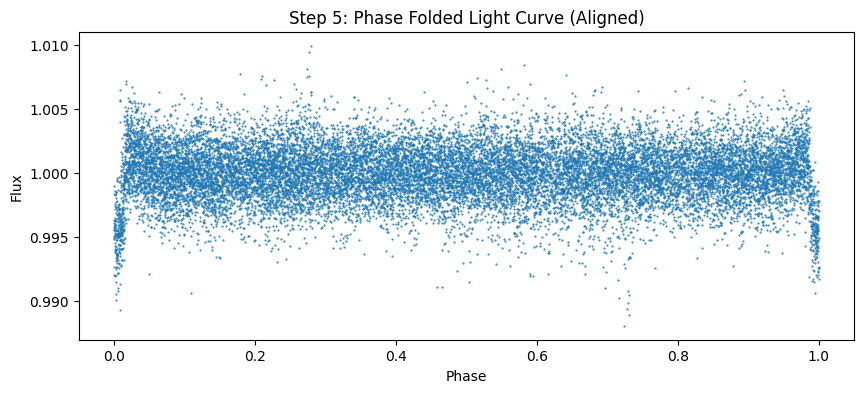

In [6]:
# =========================================================
# Step 5: Phase Folding 
# =========================================================

phase = ((time - t0) / P) % 1

plt.figure(figsize=(10,4))
plt.plot(phase, flux_flat, '.', markersize=1)
plt.title("Step 5: Phase Folded Light Curve (Aligned)")
plt.xlabel("Phase")
plt.ylabel("Flux")



plt.savefig("figures/step5_phase.png", dpi=300, bbox_inches='tight')
plt.show()

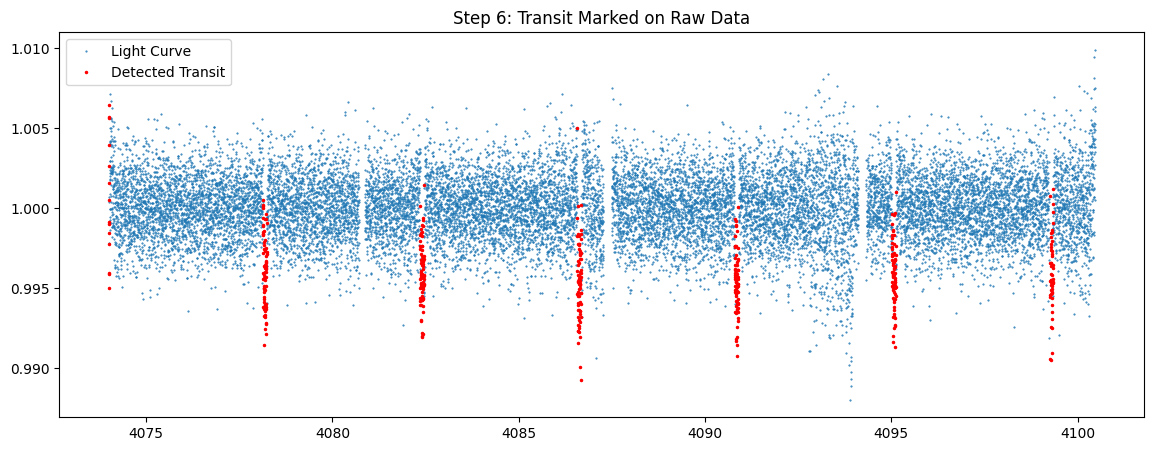

In [7]:
# =========================================================
# Step 6: Model-based Transit Reconstruction
# =========================================================

in_transit = bls.transit_mask(time, P, Tdur, t0)

plt.figure(figsize=(14,5))

plt.plot(time, flux_flat, '.', markersize=1, label="Light Curve")

plt.plot(
    time[in_transit],
    flux_flat[in_transit],
    'r.',
    markersize=3,
    label="Detected Transit"
)

plt.title("Step 6: Transit Marked on Raw Data")
plt.legend()


plt.savefig("figures/step6_transit.png", dpi=300, bbox_inches='tight')
plt.show()
